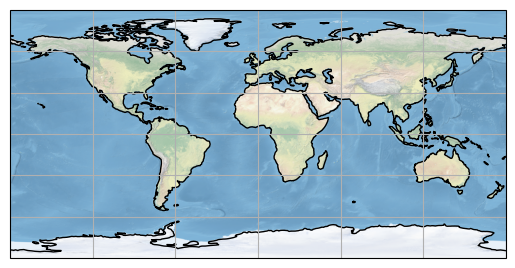

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 利用matplotlib创建Figure和Axes
plt.figure()
# ccrs.PlateCarree()定义了一个等距圆柱投影
# 该投影经常在使用WGS 84（EPSG:4326）坐标系作图的时候使用
ax = plt.axes(projection=ccrs.PlateCarree())
# 给地图添加低分辨率的地形图背景
ax.stock_img()
# 给地图添加海岸线
ax.coastlines()
# 给地图添加格网
ax.gridlines()
plt.savefig('CartoPy1.png', dpi=300)
plt.show()

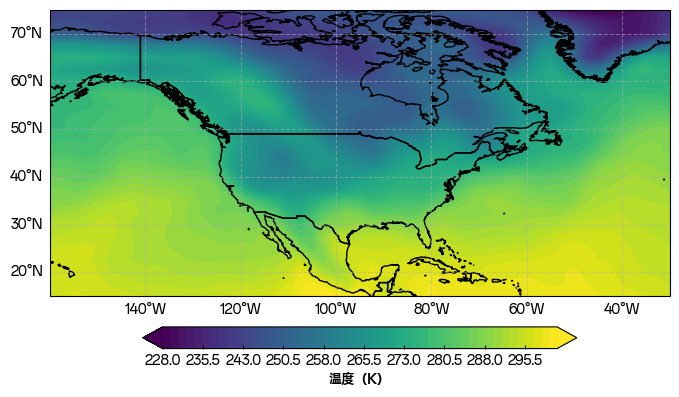

In [9]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.io.shapereader as shpreader

import matplotlib as mpl
mpl.rc("font",family='OPPO Sans')

# 使用netCDF4读取NC中存储中的温度变量
fn_nc = '/Volumes/17791433453/GeoPy/air_temperature.nc'
fn_shp = '/Volumes/17791433453/GeoPy/world-administrative-boundaries/world-administrative-boundaries.shp'
ds = nc.Dataset(fn_nc)
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
temperature = np.asarray(ds.variables['air'])[0]
# 使用cartopy提供的shapereader读取边界矢量数据
boundary = shpreader.Reader(fn_shp).geometries()

# 根据上面读取的经纬度数据构建经纬度格网用于温度数据绘制
lon_grid, lat_grid = np.meshgrid(lon, lat)
proj = ccrs.PlateCarree()
# 和使用matplotlib绘图普通图一样创建Figure和Axes
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=proj)
# 通过contourf()函数绘制温度，设置色带
cf = ax.contourf(lon_grid, lat_grid, temperature, levels=50, cmap=plt.cm.viridis,
                 transform=proj, extend='both')
# 制作颜色图例并设置其他修饰元素
cb = fig.colorbar(cf, shrink=0.70, orientation='horizontal', pad=0.08)
cb.ax.set_xlabel('温度（K）', fontweight='bold')
cb.ax.tick_params(which='major', direction='in', length=3)
# 添加国界矢量数据
ax.add_geometries(boundary, proj, facecolor='none', edgecolor='k', linewidth=1, zorder=1)
# 添加经纬度格网，设置只显示左边和下边的标签
gl = ax.gridlines(alpha=0.5, linestyle='--', draw_labels=True,
                   dms=True, x_inline=False, y_inline=False)
gl.right_labels = 0
gl.top_labels = 0

plt.savefig('CartoPy2.png', dpi=300)
plt.show()